In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn import datasets ,svm, model_selection, preprocessing, metrics
from sklearn.model_selection import train_test_split

In [4]:
data = datasets.load_iris()

In [5]:
X = data.data
y= data.target

In [7]:
print(f"Data shape: {X.shape}")
print(f"Unique labels: {np.unique(y)}") # Should show 0, 1, 2 for three species
print(f"Feature names: {data.feature_names[:2]}")
print(f"Target names: {data.target_names}")

Data shape: (150, 4)
Unique labels: [0 1 2]
Feature names: ['sepal length (cm)', 'sepal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


In [34]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scale the features
# scaler = preprocessing.StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [27]:
model = svm.SVC(kernel='rbf')
model.fit(X_train, y_train)

SVC()

In [28]:
y_pred = model.predict(X_test)

In [33]:
accuracy = metrics.accuracy_score(y_test,y_pred)
print("Accuracy: ",accuracy)

Accuracy:  1.0


In [30]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



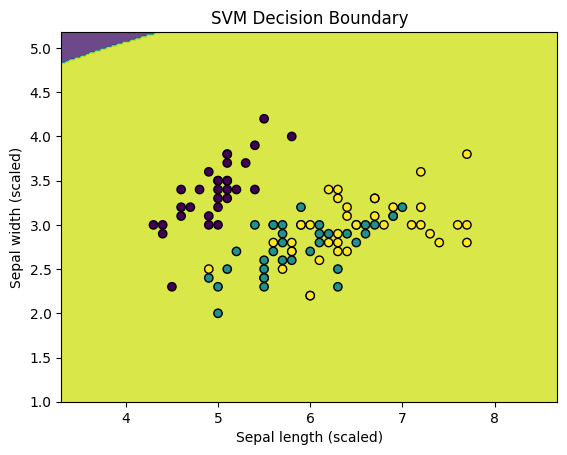

In [32]:
# Create a mesh to plot the decision boundary
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Get mean values for the other two features
mean_feature_2 = X_train[:, 2].mean()
mean_feature_3 = X_train[:, 3].mean()

# Create a 4-feature array for prediction, using the meshgrid for the first two and means for the rest
mesh_input = np.c_[xx.ravel(), yy.ravel(),
                   np.full(xx.ravel().shape, mean_feature_2),
                   np.full(xx.ravel().shape, mean_feature_3)]

Z = model.predict(mesh_input)
Z = Z.reshape(xx.shape)

# Plot the boundary and the points
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k')
plt.xlabel('Sepal length (scaled)')
plt.ylabel('Sepal width (scaled)')
plt.title('SVM Decision Boundary')
plt.show()

In [35]:
from sklearn.inspection import DecisionBoundaryDisplay

In [36]:
X = data.data[:2]
y= data.target

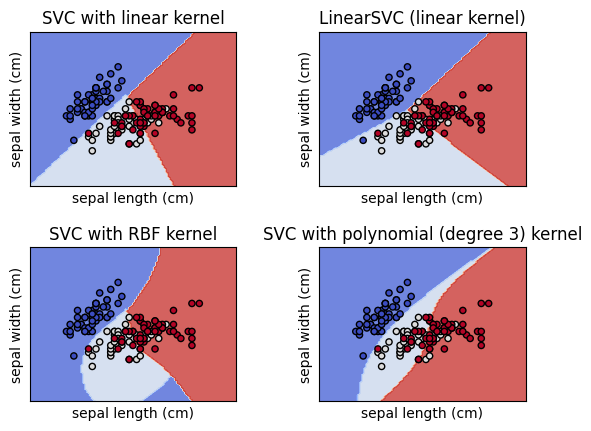

In [45]:
C = 5.0
X = data.data
y = data.target
models = (
    svm.SVC(kernel="linear", C=C),
    svm.LinearSVC(C=C, max_iter=10000),
    svm.SVC(kernel="rbf", gamma=0.7, C=C),
    svm.SVC(kernel="poly", degree=5, gamma="auto", C=C),
)
# Retrain models with only the first two features for 2D plotting
models = (clf.fit(X[:, :2], y) for clf in models)

# title for the plots
titles = (
    "SVC with linear kernel",
    "LinearSVC (linear kernel)",
    "SVC with RBF kernel",
    "SVC with polynomial (degree 3) kernel",
)

# Set-up 2x2 grid for plotting.
fig, sub = plt.subplots(2, 2)
plt.subplots_adjust(wspace=0.4, hspace=0.4)

X0, X1 = X[:, 0], X[:, 1]

for clf, title, ax in zip(models, titles, sub.flatten()):
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X[:, :2], # Use only the first two features for plotting
        response_method="predict",
        cmap=plt.cm.coolwarm,
        alpha=0.8,
        ax=ax,
        xlabel=data.feature_names[0],
        ylabel=data.feature_names[1],
    )
    ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)

plt.show()

In [51]:
model = svm.SVC(kernel="rbf", gamma=0.7, C=5)

In [53]:
model.fit(X_train, y_train)

SVC(C=5, gamma=0.7)

In [54]:
y_pred = model.predict(X_test)

In [58]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

